# 06 · Find unusual reviews (anomaly detection, unsupervised)

**Use case.** The marketplace team wants a first pass at suspicious reviews — text that does not fit the product, ratings out of line with the words — without labelled examples.

**Model / lane:** GraphMAE (self-supervised), anomaly scoring on the node embeddings

**What you will learn**
1. Define an unsupervised **anomaly detection** task on `review`
2. Train GraphMAE and score reviews by reconstruction error
3. Read the anomaly score distribution and the threshold from the Model tab — as an image
4. Score a sample: which are flagged, with what score, and what they say

**What this costs.** one GPU training run (a few minutes on `g4dn.2xlarge`; the API reserves the estimate — about 8,700 credits on the Team plan — and refunds the unused minutes, so a 90-second run ends up costing a few hundred), plus 50 credits per on-demand prediction. A re-run that finds the finished model pays only for its predictions.

> Every cell below ran for real against `api.langsat.ai` — the outputs are what the API returned. Re-running is safe:
> projects are found by name and reused, and a finished model is not retrained.

In [1]:
import sys, json
sys.path.insert(0, "..")
from _common import connect, get_or_create_project, print_schema, train_or_reuse, credits_used, save_metrics, show, fig, metrics_table, project_models
from langsat import viz
import pandas as pd

ls = connect()

signed in as team@langsat.ai · tier team · key 'TEST-SDK-4' with 20 scopes


In [2]:
p = get_or_create_project(ls, "review-anomalies", kind="data_science")
before = credits_used(ls)

reusing project 828e4626-323e-4bee-9de4-7c825f7835d3 (amazon-reviews-review-anomalies, status=ready)
files already uploaded: ['customer.csv', 'product.csv', 'review.csv'] — skipping the upload
schema already detected — skipping
project ready: status=ready · type=data_science · files=['customer.csv', 'product.csv', 'review.csv']


*Data.* The same three CSVs as chapter 01, uploaded the same way (`projects.create` → `sources.upload` → `schema.detect()`); a `data_science` project skips the clean step because the training pipeline cleans. `get_or_create_project` runs those calls and prints what it skips on a re-run — the step-by-step version with outputs is in [01](../01_setup_and_explore/).

## Define the task, train

The task is one sentence. `train_or_reuse` prints the config Langsat derived (entity table, target, which text columns get embedded), the estimate, then polls the run and reuses a finished model on re-runs. 

In [3]:
model = train_or_reuse(p, "Detect unusual or suspicious reviews based on their text, rating and the product and customer they belong to",
                       task_type="unsupervised", subtask_type="anomaly_detection", enable_text_embedding=True)
metrics = model["metrics"]
show(metrics)

reusing model 1489addf-1a1b-46c5-874d-afcbd9297d66 (unsupervised, trained 2026-09-15T09:02:48.659250+00:00)
  epoch                  100
  val_loss               0.6214


## The Model tab, as images

After training the app builds a **Model** tab: overview, feature importance, training curves and the task-specific
cards. It is a normal dashboard tab whose widgets carry Plotly JSON, so `viz.model_dashboard(p)` draws exactly what the
app shows — and `viz.model_cards(p)` lets you pick one card. The Model Overview table carries numbers the API's
`metrics` dict does not (they live only in the trained model's metadata).

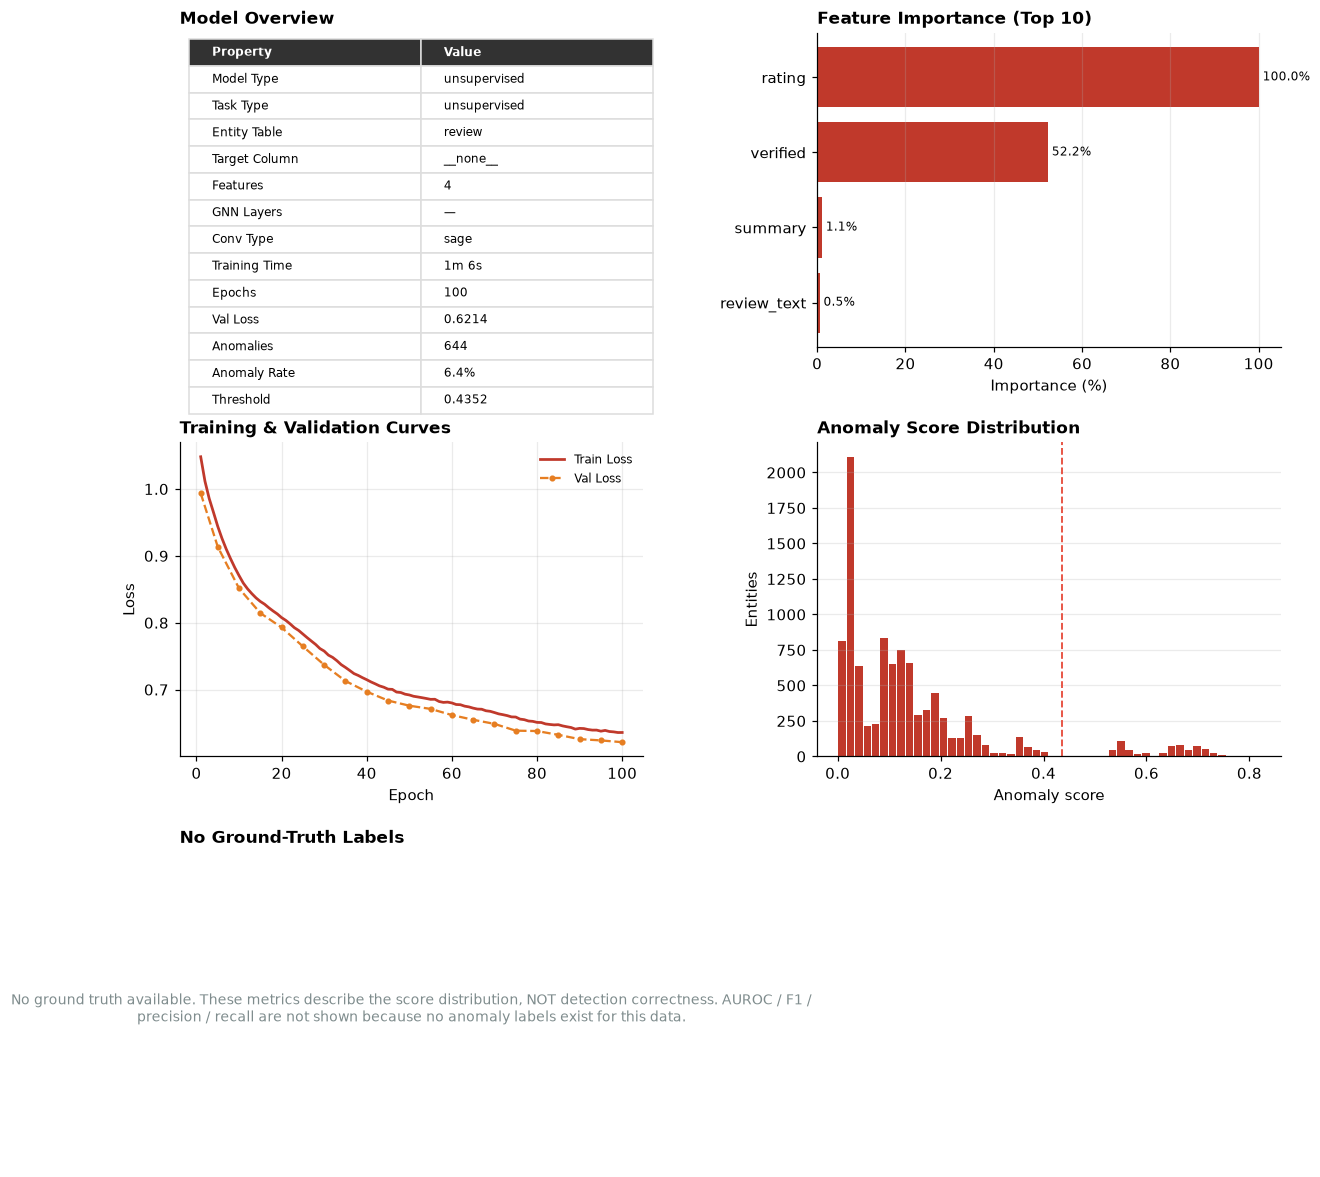

In [4]:
fig(viz.model_dashboard(p, cols=2))

The **Anomaly Score Distribution** card is the one to read: the dashed line is the cut the run chose; everything to its right is flagged. The card's description quotes the score separation (how far the flagged mean sits from the normal mean).

Distribution of anomaly scores; the dashed line is the flagged/normal cut. Score separation = 0.5250 — cut sharpness, NOT accuracy (circular; no ground truth).
threshold: 0.4352


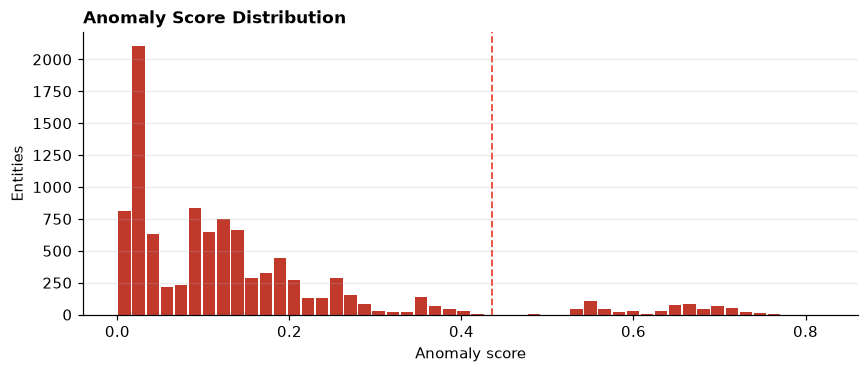

In [5]:
card = viz.model_cards(p)["Anomaly Score Distribution"]
print(card.get("description"))
threshold = card["plotly"]["layout"]["shapes"][0]["x0"]
print("threshold:", round(threshold, 4))
fig(viz.draw(card, figsize=(8, 3.5)))

## Score a sample

Anomaly detection is self-supervised too: a review whose embedding the model reconstructs badly is unusual for its neighbourhood (its product, its customer, its words). Score 30 reviews (50 credits each) and look at the flagged ones.

In [6]:
review = p.table("review").to_pandas()
sample = review.sample(30, random_state=7)
ids = sample.index.tolist()                      # review's key is the synthetic row id
batch = ls.predict.predict_batch(model_id=model["model_id"], entity_ids=ids)
sample = sample.assign(is_anomaly=[pr.get("is_anomaly") for pr in batch["predictions"]],
                       score=[pr.get("anomaly_score") for pr in batch["predictions"]])
print("flagged:", int(sample["is_anomaly"].fillna(False).astype(bool).sum()), "of", len(sample), "· threshold:", round((batch["predictions"][0] or {}).get("threshold", 0), 4))
for _, r in sample.sort_values("score", ascending=False).head(6).iterrows():
    print(f"  {'⚑' if r['is_anomaly'] else ' '} score {r['score']:.3f} · {r['rating']}★ · {str(r['summary'])[:40]!r} · {str(r['review_text'])[:90]!r}")

flagged: 2 of 30 · threshold: 0.4352
  ⚑ score 0.721 · 1★ · 'The author might do better attending her' · "Stars? None! I'm still agonizing to finish this verbosity monster. The author might do bet"
  ⚑ score 0.703 · 1★ · 'Not That Good. Lies was Much Better' · 'I really enjoyed&nbsp;<a data-hook="product-link-linked" class="a-link-normal" href="/Lies'
    score 0.288 · 4★ · "The end of the author's road" · 'This book gave a terrific description of life in Scotland, probably, back in the early 19t'
    score 0.258 · 4★ · 'Four Stars' · 'Good book. Wrapped up the story nicely'
    score 0.198 · 4★ · 'L' · 'I spent my teenage years in Minneapolis, right near the setting for this book.  I remember'
    score 0.164 · 5★ · 'Fun read' · 'What a fun read this was! I really enjoyed the way this book was written. It was first per'


In [7]:
charged = credits_used(ls) - before
save_metrics(".", {"notebook": "06_review_anomaly", "task": "anomaly detection · review (unsupervised)", "model": model.get("model_type"),
                   "project_id": p.id, "model_id": model["model_id"], "training_duration_sec": model.get("training_duration_sec"),
                   "credits_charged_this_run": charged,
                   "headline": {"val_loss": metrics.get("val_loss"), "threshold": round(float(threshold), 4), "flagged_in_sample": int(sample["is_anomaly"].fillna(False).astype(bool).sum()), "sample_size": len(sample)}})

wrote results/metrics.json


PosixPath('results/metrics.json')

## Where to go next

- [07 · Forecast](../07_forecast_review_volume/) — zero-shot, no training at all